Problem Statement - Predicting whether a rider is a Member or a Casual user, from ride behavior alone

Knowing this will help in more accurate and targeted conversion campaign   

In [10]:
import pandas as pd

citibike_df = pd.read_csv("/Users/prathibha/Downloads/202601-citibike-tripdata/202601-citibike-tripdata_1.csv")
citibike_df.head()
citibike_df.shape

/var/folders/px/dr6xn_w53090bszvy3btk0780000gn/T/ipykernel_97702/2485274464.py:3: DtypeWarning: Columns (0: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  citibike_df = pd.read_csv("/Users/prathibha/Downloads/202601-citibike-tripdata/202601-citibike-tripdata_1.csv")


(1000000, 13)

In [8]:
citibike2_df = pd.read_csv("/Users/prathibha/Downloads/202601-citibike-tripdata/202601-citibike-tripdata_2.csv")
citibike2_df.head()
citibike2_df.shape

(816391, 13)

In [12]:
df = pd.concat([citibike_df, citibike2_df], ignore_index=True)

In [13]:
df.shape

(1816391, 13)

In [14]:
df.dtypes

ride_id                   str
rideable_type             str
started_at                str
ended_at                  str
start_station_name        str
start_station_id          str
end_station_name          str
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual             str
dtype: object

In [16]:
df.isna().sum()  #missing values in each column

ride_id                  0
rideable_type            0
started_at               0
ended_at                 0
start_station_name    1334
start_station_id      1334
end_station_name      7100
end_station_id        8799
start_lat             1334
start_lng             1334
end_lat               8731
end_lng               8731
member_casual            0
dtype: int64

In [19]:
df["member_casual"].value_counts() #to check if there is an overwhelming imbalance 
#df["rideable_type"].value_counts()

member_casual
member    1653344
casual     163047
Name: count, dtype: int64

**Impression**

There is an overwhelming imbalance in the no. of members and no. of casual riders in the dataset.
Training a dataset without any corrective measures to address this imbalance will lead the classification model to majorly classify most data as member

**Steps**

Need to balance member_casual to maintain same ratios in both training and test dataset
Need to train the model to pay attention to casual more given that it is in such low numbers

In [17]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,85744AF35D7F2DF5,electric_bike,2026-01-02 05:36:24.539,2026-01-02 05:42:21.153,W 42 St & 8 Ave,6602.05,E 58 St & Madison Ave,6839.04,40.757570,-73.990985,40.763026,-73.972095,member
1,9D18958E5788880B,electric_bike,2026-01-02 15:15:11.915,2026-01-02 15:18:40.462,Division St & Bowery,5311.08,Clinton St & Grand St,5303.06_,40.714190,-73.996730,40.715738,-73.986990,member
2,B050891B7B009EE5,electric_bike,2026-01-12 10:12:51.453,2026-01-12 10:16:55.731,Broadway & 31 St,6789.08,35 Ave & 37 St,6563.12,40.761940,-73.925130,40.755733,-73.923661,member
3,0B6D7938C4EF1668,electric_bike,2026-01-01 01:03:29.712,2026-01-01 01:05:37.341,34 St & 35 Ave,6605.08,35 St & Broadway,6750.16,40.756933,-73.926223,40.760339,-73.922243,member
4,95415F60C7120CC3,electric_bike,2026-01-03 19:55:51.636,2026-01-03 20:14:57.964,E 6 St & Ave B,5584.04,W 55 St & 6 Ave,6809.09,40.724537,-73.981854,40.763189,-73.978434,member


**EDA**

**Avg Ride duration of member vs casual**
-Hypothesis = Member duration will be short and clustered evenly consistently

**Rideable_type - member vs casual**
- Hypothesis = Casual riders will overwhelmingly prefer ebikes as they might tend to want to go farther and longer with least effort

**Ride distribution over a day(hour of the day)**
- Hypothesis = Members will have peaks just before 9am and just after 5pm

**Ride distribution over a week(day of the week)**
- Hypothesis = Members will have low peaks on Saturday and Sunday while casual riders will have a peak on Sat / Sunday

**Geospatial signals**

A way to see if ride originating / ending in a certain lat,long has any pattern wrt member_casual
- Distance
- starting and ending at the same place signals leisure?

**Avg Ride duration of member vs casual**

-Hypothesis = Member duration will be short and clustered evenly consistently

Can Ride duration be used as a signal / feature for the model?
Can Ride duration be used to differentiate a casual vs member rider?

In [20]:
df["started_at"] = pd.to_datetime(df["started_at"])
df["ended_at"] = pd.to_datetime(df["ended_at"])
df["trip_duration_min"] = (df["ended_at"] - df["started_at"]).dt.total_seconds() / 60

In [21]:
df["trip_duration_min"]

0           5.943567
1           3.475783
2           4.071300
3           2.127150
4          19.105467
             ...    
1816386    24.148533
1816387     6.906083
1816388     4.687983
1816389    11.554500
1816390    14.934567
Name: trip_duration_min, Length: 1816391, dtype: float64

In [22]:
df.groupby("member_casual")["trip_duration_min"].describe()

,count,mean,std,min,25%,50%,75%,max
member_casual,,,,,,,,
casual,163047.0,15.978255,54.820535,1.004567,5.905192,9.545783,16.072667,1499.950483
member,1653344.0,10.451176,31.873493,0.082767,4.513217,7.327683,12.052283,1499.962833


Looking at max suggests that there might be some large values skewing the data - this might be cases where the ride was auto stopped after 1499 mins(~25 hours)

Need to check how many such rides are there and maybe remove them and check the stats again
Anything greater than 3 hours maybe?


Possibility 1: long trips are genuine behavior — casual riders (tourists, leisure users) actually take longer rides than members (commuters)
Possibility 2 : long trips are a data problem — bikes not properly docked, lost, or a system glitch, possibly more common among casual riders since they have less accountability tied to their account

In [30]:
# Band 0: borderline leisure vs regular commute 
band0 = df[(df["trip_duration_min"] > 45) & (df["trip_duration_min"] <= 60)]
print("45-60 min:", len(band0))

# Band 1: probably leisure use - 1 - 3 hours
band1 = df[(df["trip_duration_min"] > 60) & (df["trip_duration_min"] <= 180)]
print("60-180 min:", len(band1))

# Band 2: ambiguous long trips - 3 - 23 hours
band2 = df[(df["trip_duration_min"] > 180) & (df["trip_duration_min"] < 1490)]
print("180-1490 min:", len(band2))

# Band 3: near the suspicious ceiling - 23-24 hours
band3 = df[df["trip_duration_min"] >= 1490]
print(">=1490 min:", len(band3))

# check the split by member_casual for each band
for name, band in [("45-60 mins", band0), ("60-180 mins", band1), ("180-1490mins", band2), ("1490+ mins", band3)]:
    print(f"\n{name} member_casual split:")
    print(band["member_casual"].value_counts(normalize=True))

45-60 min: 9311
60-180 min: 6787
180-1490 min: 1368
>=1490 min: 636

45-60 mins member_casual split:
member_casual
member    0.739341
casual    0.260659
Name: proportion, dtype: float64

60-180 mins member_casual split:
member_casual
member    0.618683
casual    0.381317
Name: proportion, dtype: float64

180-1490mins member_casual split:
member_casual
member    0.69883
casual    0.30117
Name: proportion, dtype: float64

1490+ mins member_casual split:
member_casual
member    0.759434
casual    0.240566
Name: proportion, dtype: float64


This suggests that these are genuine usecases which show a corelation between casual riders and the ride duration.

These might not be cases of "rider sloppily parked and did not end ride" OR "system auto ended ride after a set time due to inactivity" 

If long trips were mostly data errors or lost bikes, you wouldn't expect casual riders to be so consistently over-represented across all duration bands (given that the share of casual riders in overall dataset is around 9%) — you'd expect it to be random or concentrated in one weird band (maybe in the extreme 1490+ group). 
Instead, it's a consistent pattern in all bands, which looks like real behavior: casual riders genuinely tend to take longer rides than members.

Conclusion : Possibility 1 is true and duration is a valuable signal

In [24]:
df[df["trip_duration_min"] >= 1490]["trip_duration_min"].value_counts().head(10)

trip_duration_min
1499.672783    2
1499.820333    2
1499.621317    2
1499.907483    2
1499.884883    2
1499.845350    2
1499.909433    2
1499.893400    2
1499.647750    2
1499.822433    2
Name: count, dtype: int64

**Rideable_type - member vs casual**
- Hypothesis = Casual riders will overwhelmingly prefer ebikes as they might tend to want to go farther and longer with least effort

In [35]:
pd.crosstab(df["rideable_type"], df["member_casual"], normalize="columns") 
#To see if rideable_type can be a signal to denote casual riders also

member_casual,casual,member
rideable_type,,
classic_bike,0.17468,0.284615
electric_bike,0.82532,0.715385


In [34]:
pd.crosstab(df["rideable_type"], df["member_casual"])

member_casual,casual,member
rideable_type,,
classic_bike,28481,470567
electric_bike,134566,1182777


Looks like casual riders do use electric_bike more than the classic_bike; 
Eventhough this behaviour is consistent with members as well, the % is a bit higher in casual riders when compared to members
This can be added as a feature for the model

**Ride distribution over a day(hour of the day)**
- Hypothesis = Members will have peaks just before 9am and just after 5pm; casual riders will ride on a leisure schedule.

In [47]:
# Hour of day
df["hour"] = df["started_at"].dt.hour
pd.crosstab(df["hour"], df["member_casual"], normalize="columns")


member_casual,casual,member
hour,,
0,0.022129,0.011413
1,0.016498,0.007088
2,0.011665,0.004788
3,0.008010,0.003228
4,0.006489,0.003656
5,0.009709,0.009905
6,0.017983,0.025438
7,0.035045,0.052446
8,0.051004,0.080923


<Axes: xlabel='hour'>

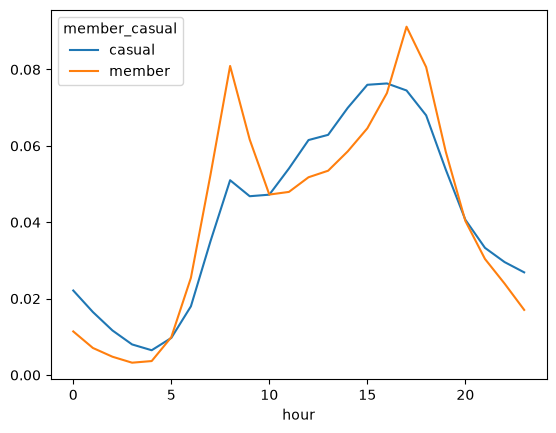

In [49]:
import matplotlib

pd.crosstab(df["hour"], df["member_casual"], normalize="columns").plot()#.set_xticks(range(24))


The shape confirms that the members do have two sharpeaks signalling the 9-5 behaviour where as the casual riders have a more plateued effect that clusters mainly around midday or post lunch signalling leisurely activities

Hour of the day can be used as a signal/feature

**Ride distribution over a week(day of the week)**
- Hypothesis = Members will have low peaks on Saturday and Sunday while casual riders will have a peak on Sat / Sunday


In [52]:
df.head()


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,trip_duration_min,hour
0,85744AF35D7F2DF5,electric_bike,2026-01-02 05:36:24.539,2026-01-02 05:42:21.153,W 42 St & 8 Ave,6602.05,E 58 St & Madison Ave,6839.04,40.757570,-73.990985,40.763026,-73.972095,member,5.943567,5
1,9D18958E5788880B,electric_bike,2026-01-02 15:15:11.915,2026-01-02 15:18:40.462,Division St & Bowery,5311.08,Clinton St & Grand St,5303.06_,40.714190,-73.996730,40.715738,-73.986990,member,3.475783,15
2,B050891B7B009EE5,electric_bike,2026-01-12 10:12:51.453,2026-01-12 10:16:55.731,Broadway & 31 St,6789.08,35 Ave & 37 St,6563.12,40.761940,-73.925130,40.755733,-73.923661,member,4.071300,10
3,0B6D7938C4EF1668,electric_bike,2026-01-01 01:03:29.712,2026-01-01 01:05:37.341,34 St & 35 Ave,6605.08,35 St & Broadway,6750.16,40.756933,-73.926223,40.760339,-73.922243,member,2.127150,1
4,95415F60C7120CC3,electric_bike,2026-01-03 19:55:51.636,2026-01-03 20:14:57.964,E 6 St & Ave B,5584.04,W 55 St & 6 Ave,6809.09,40.724537,-73.981854,40.763189,-73.978434,member,19.105467,19


In [54]:
df["dow"] = df["started_at"].dt.weekday
pd.crosstab(df["dow"], df["member_casual"], normalize="columns")

member_casual,casual,member
dow,,
0,0.102112,0.120536
1,0.117488,0.147441
2,0.145222,0.165515
3,0.189467,0.190609
4,0.182892,0.179449
5,0.141199,0.110938
6,0.121621,0.085513


<Axes: xlabel='dow'>

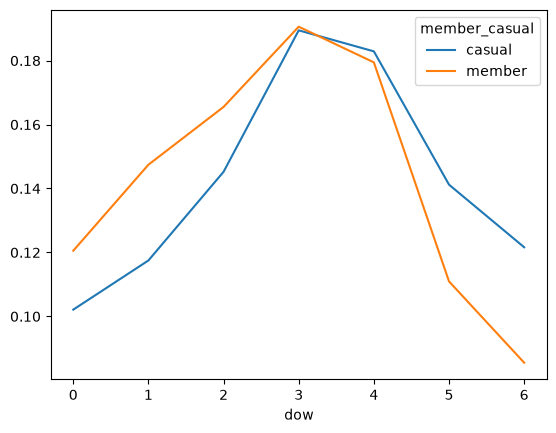

In [56]:
pd.crosstab(df["dow"], df["member_casual"], normalize="columns").plot()#.set_xticks(range(24))
#0 = Monday .... 6 = Sunday

As seen by the shape, the casual riders have a significantly higher ridership as compared to commute based members on Saturday and especially Sundays (which is the weekoff from work)

But, it is also to be noted that both the ridership converges on Wednesday - which kinda weakens the signal a bit;

While DoW in itself cannot be a clear signal, it can be used alongside the Hour of Week as a reinforcement.

**Geospatial signals**

**Trip distance**

Do casual riders cover more ground (sightseeing, exploring) or less (short novelty rides) than members (efficient point-A-to-B commutes)?

In [59]:
import numpy as np

def haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df["trip_distance_km"] = haversine_vectorized(
    df["start_lat"], df["start_lng"], df["end_lat"], df["end_lng"]
)

In [65]:
#df["trip_distance_km"]

df["trip_distance_km"].isna().sum()

np.int64(9769)

In [66]:
df[df["trip_distance_km"].isna()]["member_casual"].value_counts(normalize=True)

member_casual
member    0.834169
casual    0.165831
Name: proportion, dtype: float64

In [69]:
df = df.dropna(subset=["trip_distance_km"]) 
#~1% of rows had missing location data, skewed toward casual riders (16.6% vs 9% baseline) — likely related to incomplete dockings;
# dropped these rows, so distance findings may slightly underrepresent unusual casual trips

In [68]:
df.groupby("member_casual")["trip_distance_km"].describe()

,count,mean,std,min,25%,50%,75%,max
member_casual,,,,,,,,
casual,161427.0,1.881266,1.482073,0.0,0.931648,1.482509,2.401988,19.816927
member,1645195.0,1.726343,1.438611,0.0,0.793096,1.312280,2.186166,26.462454


In [70]:
df["distance_bucket"] = pd.cut(
    df["trip_distance_km"],
    bins=[0, 0.5, 1, 1.5, 2, 3, 5, 30],
    labels=["0-0.5km", "0.5-1km", "1-1.5km", "1.5-2km", "2-3km", "3-5km", "5km+"]
)
pd.crosstab(df["distance_bucket"], df["member_casual"], normalize="columns")

member_casual,casual,member
distance_bucket,,
0-0.5km,0.044325,0.092443
0.5-1km,0.209592,0.259220
1-1.5km,0.233540,0.215202
1.5-2km,0.165409,0.141041
2-3km,0.176997,0.150684
3-5km,0.126051,0.102908
5km+,0.044087,0.038503


Members disproportionately take short, quick trips — the "grab a bike for 3 blocks" commute pattern. 
Casual riders skew toward the 1-5km range — consistent with the sightseeing/leisure hypothesis, longer deliberate rides rather than utilitarian short hops.

Conclusion : Trip distance can be used as a signal/feature

**Station loop**

Did the trip start and end at the same dock (a loop, likely leisure/exercise, not commute)?

In [72]:
df["same_station"] = (
    df["start_station_id"].astype(str) == df["end_station_id"].astype(str)
).astype(int)

pd.crosstab(df["same_station"], df["member_casual"], normalize="columns")

member_casual,casual,member
same_station,,
0,0.96311,0.98721
1,0.03689,0.01279


Casual riders return to their starting station about 3 times more often than members (3.7% vs 1.3%) — small in absolute terms, but a real, consistent gap in the same direction as other signals

This fits the pattern: a member on a commute goes point A to point B by definition — looping back to start makes no sense for getting to work. 
A casual rider doing a leisure loop (ride around the park, explore, come back) is a much more plausible scenario. 

**EDA Conclusion**

| Feature | Direction | Signal Strength |
|---|---|---|
| Trip duration | Casual > Member | Strong |
| Trip distance | Casual > Member | Moderate |
| Rideable type (e-bike %) | Casual > Member | Moderate |
| Hour-of-day shape | Casual flatter, Member two-peaked (commute) | Strong |
| Day-of-week (weekend share) | Casual > Member | Moderate |
| Same-station (loop trips) | Casual > Member | Weak but consistent |

**Creating the train - test datasets**

Features

In [78]:
# Target
y = df["member_casual"]

# Features
features = df[[
    "trip_duration_min",
    "trip_distance_km",
    "hour",
    "dow",
    "rideable_type",
    "same_station"
]].copy()

# Encode rideable_type (binary — only 2 categories)
features["is_electric"] = (features["rideable_type"] == "electric_bike").astype(int)
features = features.drop(columns=["rideable_type"])

# One-hot encode dow - feeding it in as a plain integer implies an order (day 6 > day 5 > day 4...) which isn't really true
features = pd.get_dummies(features, columns=["dow"], drop_first=True)

In [83]:
features.shape

(1806622, 11)

In [80]:
features.head()

,trip_duration_min,trip_distance_km,hour,same_station,is_electric,dow_1,dow_2,dow_3,dow_4,dow_5,dow_6
0,5.943567,1.702730,5,0.0,1,False,False,False,True,False,False
1,3.475783,0.838759,15,0.0,1,False,False,False,True,False,False
2,4.071300,0.701221,10,0.0,1,False,False,False,False,False,False
3,2.127150,0.505782,1,0.0,1,False,False,True,False,False,False
4,19.105467,4.307516,19,0.0,1,False,False,False,False,True,False


In [81]:
features.dtypes

trip_duration_min    float64
trip_distance_km     float64
hour                   int32
same_station         float64
is_electric            int64
dow_1                   bool
dow_2                   bool
dow_3                   bool
dow_4                   bool
dow_5                   bool
dow_6                   bool
dtype: object

In [82]:
features.isna().sum()

trip_duration_min     0
trip_distance_km      0
hour                  0
same_station         68
is_electric           0
dow_1                 0
dow_2                 0
dow_3                 0
dow_4                 0
dow_5                 0
dow_6                 0
dtype: int64

In [84]:
df[df["same_station"].isna()][["start_station_id", "end_station_id"]]

,start_station_id,end_station_id
796846,7567.06,NaN
796970,5348.06,NaN
797802,8068.01,NaN
799755,7161.08,NaN
800520,3495.08,NaN
...,...,...
1538357,6644.04,NaN
1539479,7235.13,NaN
1540032,6254.06,NaN
1540331,7720.03,NaN


In [85]:
features = features.dropna(subset=["same_station"])
y = y.loc[features.index]  # keep target aligned with features after dropping rows

In [86]:
features.isna().sum()

trip_duration_min    0
trip_distance_km     0
hour                 0
same_station         0
is_electric          0
dow_1                0
dow_2                0
dow_3                0
dow_4                0
dow_5                0
dow_6                0
dtype: int64

Train / Test split

In [91]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    features, y, test_size=0.2, stratify=y, random_state=42, shuffle=True
)

In [92]:
print(X_train.shape, X_test.shape)


(1445243, 11) (361311, 11)


In [93]:
print(y_train.value_counts(normalize=True))


member_casual
member    0.910652
casual    0.089348
Name: proportion, dtype: float64


In [94]:
print(y_test.value_counts(normalize=True))

member_casual
member    0.91065
casual    0.08935
Name: proportion, dtype: float64


In [96]:
1445243/361311

3.9999972323012583

**Training the model** - **Logistic Regression**

In [97]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

**Predict** - **Logistic Regression**

In [98]:
y_pred = model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

      casual       0.13      0.57      0.21     32283
      member       0.94      0.63      0.75    329028

    accuracy                           0.62    361311
   macro avg       0.53      0.60      0.48    361311
weighted avg       0.86      0.62      0.70    361311

[[ 18323  13960]
 [122972 206056]]


**Confusion Matrix**

If Casual is the positive class, 
                   
               
| | Predicted Casual | Predicted Member |
|---|---|---|
| **Actual Casual** | True Positive: 18,323 | False Negative: 13,960 |
| **Actual Member** | False Positive: 122,972 | True Negative: 206,056 |


Recall for casual = correctly caught casuals / all actual casuals = true positive / (True positive + False Negative)
Precision for casual = correctly caught casuals / all predicted casuals = true positive / (True positive + False Positive)

If recall is low = false negatives are high = the model is flagging casuals as members
If precision is low = false positives are high = the model is flagging members as casuals

In our case, recall is greater than 0.5 but the precision is low 0.13 which is a problem.

We asked for class_weight = balanced, which is now showing up as members being flagged as casuals too


**Train** - **Random Forest**

In [100]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1  # uses all CPU cores, since Random Forest is slower to train than Logistic Regression
)

rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

**Predict** - **Random Forest**

In [102]:
y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

      casual       0.20      0.17      0.19     32283
      member       0.92      0.93      0.93    329028

    accuracy                           0.87    361311
   macro avg       0.56      0.55      0.56    361311
weighted avg       0.86      0.87      0.86    361311

[[  5618  26665]
 [ 21890 307138]]


The recall is actually worse for the Random Forest - even if the accuracy seem improved

In [103]:
# get probability of "casual" instead of a hard 0/1 prediction
probs = rf_model.predict_proba(X_test)[:, 0]  # index 0 = 'casual', per classes_ order

# try a few thresholds
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = (probs >= threshold).astype(int)
    preds = ["casual" if p == 1 else "member" for p in preds]
    print(f"Threshold: {threshold}")
    print(classification_report(y_test, preds, labels=["casual", "member"]))
    print("---")

Threshold: 0.3
              precision    recall  f1-score   support

      casual       0.15      0.35      0.21     32283
      member       0.93      0.81      0.87    329028

    accuracy                           0.77    361311
   macro avg       0.54      0.58      0.54    361311
weighted avg       0.86      0.77      0.81    361311

---
Threshold: 0.4
              precision    recall  f1-score   support

      casual       0.18      0.25      0.21     32283
      member       0.92      0.89      0.90    329028

    accuracy                           0.83    361311
   macro avg       0.55      0.57      0.56    361311
weighted avg       0.86      0.83      0.84    361311

---
Threshold: 0.5
              precision    recall  f1-score   support

      casual       0.20      0.17      0.19     32283
      member       0.92      0.93      0.93    329028

    accuracy                           0.87    361311
   macro avg       0.56      0.55      0.56    361311
weighted avg       0.

Hyperparameter tuning on **Random Forest** - Default Random Forest let trees grow unconstrained (max_depth=None), likely overfitting to majority-class noise. Constraining it with max depth=10

In [104]:
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fea

In [105]:
# get probability of "casual" instead of a hard 0/1 prediction
probs = rf_tuned.predict_proba(X_test)[:, 0]  # index 0 = 'casual', per classes_ order

# try a few thresholds
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = (probs >= threshold).astype(int)
    preds = ["casual" if p == 1 else "member" for p in preds]
    print(f"Threshold: {threshold}")
    print(classification_report(y_test, preds, labels=["casual", "member"]))
    print("---")

Threshold: 0.3
              precision    recall  f1-score   support

      casual       0.10      0.97      0.18     32283
      member       0.98      0.14      0.24    329028

    accuracy                           0.21    361311
   macro avg       0.54      0.55      0.21    361311
weighted avg       0.90      0.21      0.24    361311

---
Threshold: 0.4
              precision    recall  f1-score   support

      casual       0.11      0.91      0.19     32283
      member       0.97      0.25      0.40    329028

    accuracy                           0.31    361311
   macro avg       0.54      0.58      0.30    361311
weighted avg       0.89      0.31      0.38    361311

---
Threshold: 0.5
              precision    recall  f1-score   support

      casual       0.13      0.67      0.22     32283
      member       0.95      0.57      0.71    329028

    accuracy                           0.58    361311
   macro avg       0.54      0.62      0.47    361311
weighted avg       0.

**XGBoost**

In [108]:


from xgboost import XGBClassifier

y_train_binary = (y_train == "casual").astype(int)
y_test_binary = (y_test == "casual").astype(int)

xgb_model = XGBClassifier(
    scale_pos_weight=(y_train_binary == 0).sum() / (y_train_binary == 1).sum(),
    random_state=42
)
xgb_model.fit(X_train, y_train_binary)

y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test_binary, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.94      0.65      0.77    329028
           1       0.14      0.61      0.23     32283

    accuracy                           0.64    361311
   macro avg       0.54      0.63      0.50    361311
weighted avg       0.87      0.64      0.72    361311



Trip speed (distance ÷ duration) — a derived feature that might separate "leisurely meander" from "fast direct commute" better than either raw number alone

In [109]:
X_train["speed_kmh"] = X_train["trip_distance_km"] / (X_train["trip_duration_min"] / 60)
X_test["speed_kmh"] = X_test["trip_distance_km"] / (X_test["trip_duration_min"] / 60)

In [111]:
X_train["speed_kmh"] = X_train["speed_kmh"].replace([float("inf"), float("-inf")], pd.NA)
X_test["speed_kmh"] = X_test["speed_kmh"].replace([float("inf"), float("-inf")], pd.NA)

X_train = X_train.dropna(subset=["speed_kmh"])
y_train = y_train.loc[X_train.index]
X_test = X_test.dropna(subset=["speed_kmh"])
y_test = y_test.loc[X_test.index]

In [112]:
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fea

In [113]:
# get probability of "casual" instead of a hard 0/1 prediction
probs = rf_tuned.predict_proba(X_test)[:, 0]  # index 0 = 'casual', per classes_ order

# try a few thresholds
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = (probs >= threshold).astype(int)
    preds = ["casual" if p == 1 else "member" for p in preds]
    print(f"Threshold: {threshold}")
    print(classification_report(y_test, preds, labels=["casual", "member"]))
    print("---")

Threshold: 0.3
              precision    recall  f1-score   support

      casual       0.10      0.97      0.18     32283
      member       0.98      0.15      0.25    329028

    accuracy                           0.22    361311
   macro avg       0.54      0.56      0.22    361311
weighted avg       0.90      0.22      0.25    361311

---
Threshold: 0.4
              precision    recall  f1-score   support

      casual       0.11      0.90      0.19     32283
      member       0.97      0.27      0.42    329028

    accuracy                           0.33    361311
   macro avg       0.54      0.59      0.31    361311
weighted avg       0.89      0.33      0.40    361311

---
Threshold: 0.5
              precision    recall  f1-score   support

      casual       0.14      0.59      0.23     32283
      member       0.94      0.65      0.77    329028

    accuracy                           0.65    361311
   macro avg       0.54      0.62      0.50    361311
weighted avg       0.

## Conclusion

### Problem
Predict whether a Citi Bike trip belongs to a Member or Casual rider, using ride behavior alone (no demographic data available) — with the business goal of identifying casual riders whose behavior already resembles a member's, as targets for conversion.

### Key EDA findings
Six behavioral signals were tested; all pointed in the same direction — casual riders behave more like leisure/tourist users, members behave like commuters:

| Feature | Direction | Signal Strength |
|---|---|---|
| Trip duration | Casual > Member | Strong |
| Trip distance | Casual > Member | Moderate |
| Rideable type (e-bike %) | Casual > Member | Moderate |
| Hour-of-day shape | Casual flatter, Member two-peaked (commute) | Strong |
| Day-of-week (weekend share) | Casual > Member | Moderate |
| Same-station (loop trips) | Casual > Member | Weak but consistent |

### Modeling results

| Model / Change | Best Casual F1 |
|---|---|
| Logistic Regression (baseline) | 0.21 |
| Random Forest (untuned) | 0.21 |
| Random Forest (tuned depth) | 0.24 |
| XGBoost (default) | 0.23 |
| Random Forest (tuned + speed feature) | **0.25** |

### What this means
- The dataset has an inherent ~91/9 class imbalance (member/casual), which makes accuracy a misleading metric throughout — a model that always predicts "member" scores ~91% accuracy while being useless. Precision, recall, and F1 for the casual class were used instead.
- Three genuinely different model types (linear, bagged trees, boosted trees), hyperparameter tuning, a full decision-threshold sweep, and an additional engineered feature (speed = distance/duration) were all tested. F1 for the casual class moved only from 0.21 to 0.25 across all of this — a real but modest gain, with diminishing returns on each additional change.
- This convergence across different techniques is evidence that the ceiling here is largely in the **available features**, not in model choice or tuning. The six behavioral features used capture a real but limited amount of the difference between member and casual riders.

### Business takeaway
A model at this performance level (~30% recall, ~22% precision at the best operating threshold) is weak on its own but not useless — it could reasonably support a **low-cost, low-risk intervention** (e.g., an in-app nudge or email) where being wrong most of the time is an acceptable cost, but should not be used to justify an expensive or high-friction conversion campaign.

### What could improve this further (not tested here)
- Station-level features (commuter-hub vs. leisure-hub classification) — scoped out for time
- A joined external dataset (e.g., weather) for richer context
- More exhaustive hyperparameter search (grid/random search rather than manual tuning)